In [112]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, average_precision_score, precision_score, recall_score, f1_score, roc_curve,
    roc_auc_score, precision_recall_curve, auc, confusion_matrix, classification_report
)

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [113]:
# Load dataset into a DataFrame
df = pd.read_csv('data/customer_subscription_churn_usage_patterns.csv')

# Display the first 5 rows
print(f"\n\n{df.head()}\n\n")

# Dataset dimensions (rows and columns)
print(f"Total rows and columns: {df.shape}\n\n")

# Column data types and memory usage
print(f"{df.info()}\n\n")

# Check for missing values per column
print(df.isnull().sum())





   user_id signup_date plan_type  monthly_fee  avg_weekly_usage_hours  \
0        1  2023-04-15   Premium          699                     1.1   
1        2  2023-08-27   Premium          699                     2.6   
2        3  2023-10-12   Premium          699                    14.3   
3        4  2023-12-11     Basic          199                    17.6   
4        5  2023-02-14     Basic          199                     9.8   

   support_tickets  payment_failures  tenure_months  last_login_days_ago churn  
0                4                 1              8                   14   Yes  
1                6                 0             35                    1   Yes  
2                8                 3              2                   14   Yes  
3                5                 2             11                    9   Yes  
4                5                 2              6                   38   Yes  


Total rows and columns: (2800, 10)


<class 'pandas.DataFrame'>
RangeIn

In [114]:
df = df.drop(columns = ["user_id", "signup_date"])

# Remaining columns
print(df.columns.tolist())

display(df.head())

# Descriptive statistics for numerical columns
display(df.describe())

['plan_type', 'monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months', 'last_login_days_ago', 'churn']


,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,Premium,699,1.1,4,1,8,14,Yes
1,Premium,699,2.6,6,0,35,1,Yes
2,Premium,699,14.3,8,3,2,14,Yes
3,Basic,199,17.6,5,2,11,9,Yes
4,Basic,199,9.8,5,2,6,38,Yes


,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000
std,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757
min,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000
50%,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000
75%,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000
max,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000


Target Class Counts:
churn
Yes    1605
No     1195
Name: count, dtype: int64

Target Class Proportions (%):
churn
Yes    57.321429
No     42.678571
Name: proportion, dtype: float64


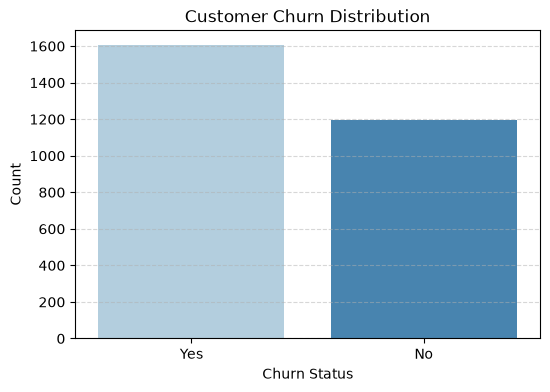

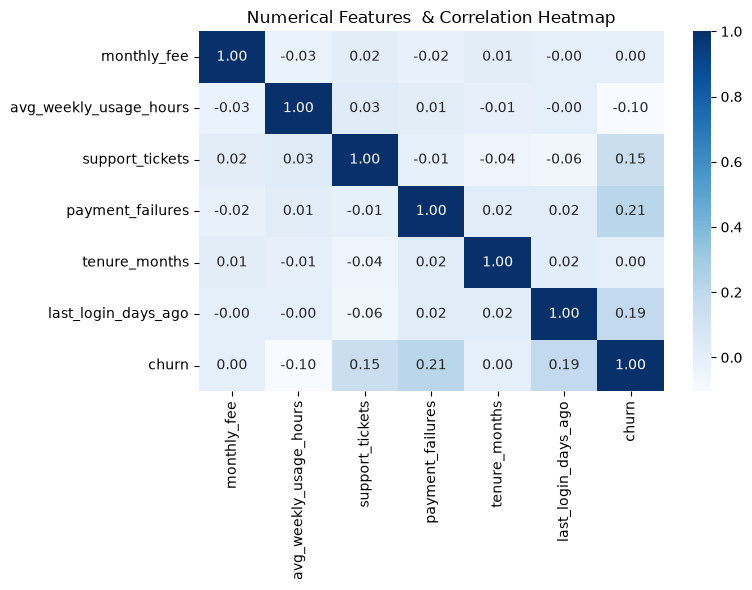

In [115]:
# Target distribution counts
churn_counts = df['churn'].value_counts()

print("Target Class Counts:")
print(churn_counts)

# Target distribution percentage
print("\nTarget Class Proportions (%):")
print(df['churn'].value_counts(normalize = True) * 100)


# Target distribution bar plot
plt.figure(figsize = (6, 4))
sns.countplot(data = df, x = 'churn',hue = "churn", palette = "Blues", legend = False)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.grid(axis = "y", linestyle = "--", alpha = 0.5)
plt.show()

# Numerical features correlation heatmap
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})
plt.figure(figsize = (8, 6))
sns.heatmap(df.select_dtypes(include = ["number"]).corr(), annot = True, cmap = "Blues", fmt = ".2f")
plt.title("Numerical Features  & Correlation Heatmap")
plt.tight_layout()
plt.show()

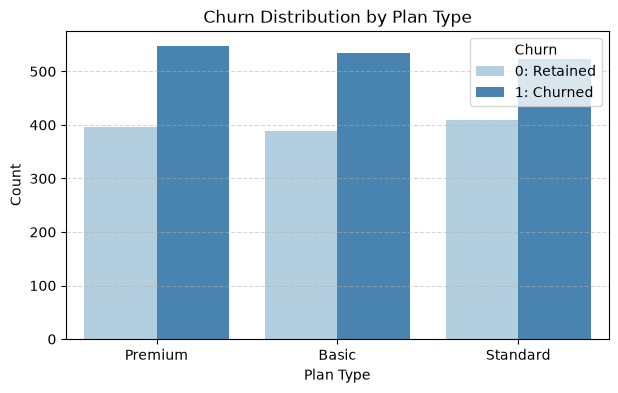

In [116]:
# Impact of plan_type on churn
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="plan_type", hue="churn", palette="Blues")
plt.title("Churn Distribution by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Count")
plt.legend(title="Churn", labels=["0: Retained", "1: Churned"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [117]:
# Convert categorical column to numeric (One-Hot Encoding)
df = pd.get_dummies(df, columns = ["plan_type"], drop_first = True, dtype = int)

# Features: X, Target: y
X = df.drop("churn", axis = 1)
y = df["churn"].values

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20, random_state = 42, stratify = y
)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Check dataset dimensions
print(f"X_train sape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Input Features: {X_train.shape[1]}")

X_train sape: (2240, 8)
X_test shape: (560, 8)
y_train shape: (2240,)
y_test shape: (560,)
Input Features: 8


In [118]:
# Custom Dataset class for PyTorch ANN
class ChurnDataset(Dataset):
    def __init__(self, X_data, y_data):
        # ANN expects shape: (Batch, Features) -> (N, 8)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        # Target shape: (Batch, 1) -> (N, 1)
        y_arr = y_data.values if hasattr(y_data, 'values') else y_data
        self.y = torch.tensor(y_arr, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Creating dataset instances
train_dataset = ChurnDataset(X_train, y_train)
test_dataset = ChurnDataset(X_test, y_test)

# DataLoaders (Train: 32 batch, Test: 64 batch)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Check first batch shape
sample_X, sample_y = next(iter(train_loader))
print(f"Sample batch X shape: {sample_X.shape}")
print(f"Sample batch y shape: {sample_y.shape}")

Sample batch X shape: torch.Size([32, 8])
Sample batch y shape: torch.Size([32, 1])


In [119]:
# ANN (Multilayer Perceptron) Architecture
class ChurnANN(nn.Module):
    def __init__(self, input_dim):
        super(ChurnANN, self).__init__()

        # Hidden Layer 1
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.3)

        # Hidden Layer 2
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.dropout2 = nn.Dropout(p=0.2)

        # Output Layer (Binary Logit)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.dropout1(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(self.relu(self.bn2(self.fc2(x))))
        x = self.fc3(x)
        return x

# Model instance
num_features = X_train.shape[1]
model = ChurnANN(input_dim=num_features)
print(model)

ChurnANN(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


In [120]:
def evaluate_sprint_metrics(y_true, y_probs, threshold=0.5, title="Model"):
    y_pred = (y_probs >= threshold).astype(int)
    
    roc_auc = roc_auc_score(y_true, y_probs)
    pr_auc = average_precision_score(y_true, y_probs)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"=== {title} (Threshold: {threshold}) ===")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"PR-AUC    : {pr_auc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print("-" * 45)
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Retained (0)', 'Churned (1)'],
                yticklabels=['Retained (0)', 'Churned (1)'])
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    return {
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

=== Version A: No Class Weight (Threshold: 0.5) ===
ROC-AUC   : 0.7224
PR-AUC    : 0.7584
Precision : 0.7052
Recall    : 0.7227
F1-Score  : 0.7138
---------------------------------------------


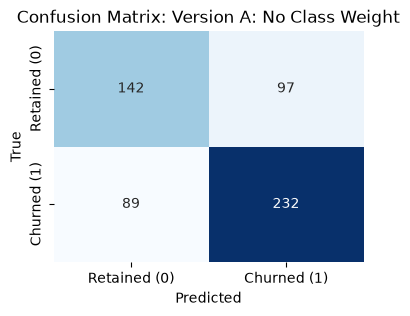

In [121]:
torch.manual_seed(42)

model_unweighted = ChurnANN(input_dim=num_features)
criterion_unweighted = nn.BCEWithLogitsLoss()
optimizer_unweighted = optim.Adam(model_unweighted.parameters(), lr=0.005)

# Training Loop
model_unweighted.train()
for epoch in range(35):
    for batch_x, batch_y in train_loader:
        optimizer_unweighted.zero_grad()
        outputs = model_unweighted(batch_x)
        loss = criterion_unweighted(outputs, batch_y)
        loss.backward()
        optimizer_unweighted.step()

# Evaluation on Test Data
model_unweighted.eval()
y_probs_unweighted = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        outputs = model_unweighted(batch_x)
        y_probs_unweighted.extend(torch.sigmoid(outputs).numpy())

y_probs_unweighted = np.array(y_probs_unweighted).ravel()

metrics_unweighted = evaluate_sprint_metrics(
    y_test, y_probs_unweighted, threshold=0.5, title="Version A: No Class Weight"
)

=== Version B: With Class Weight (Threshold: 0.5) ===
ROC-AUC   : 0.7274
PR-AUC    : 0.7654
Precision : 0.7443
Recall    : 0.6075
F1-Score  : 0.6690
---------------------------------------------


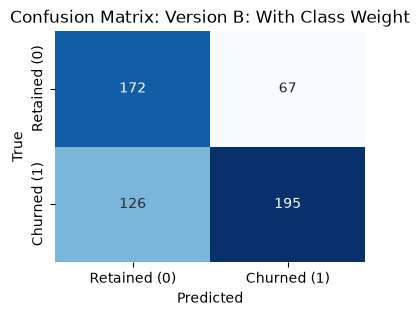

=== Version A (Tuned th=0.40) (Threshold: 0.4) ===
ROC-AUC   : 0.7224
PR-AUC    : 0.7584
Precision : 0.6581
Recall    : 0.8754
F1-Score  : 0.7513
---------------------------------------------


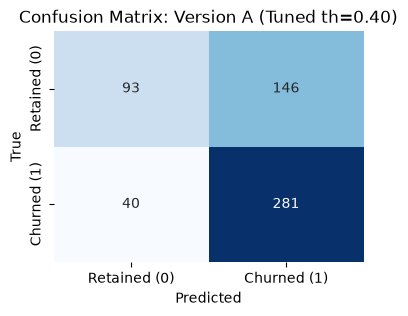

In [ ]:
torch.manual_seed(42)

num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
pos_weight = torch.tensor([num_negative / num_positive], dtype=torch.float32)

model_weighted = ChurnANN(input_dim=num_features)
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_weighted = optim.Adam(model_weighted.parameters(), lr=0.005)

# Training Loop
model_weighted.train()
for epoch in range(35):
    for batch_x, batch_y in train_loader:
        optimizer_weighted.zero_grad()
        outputs = model_weighted(batch_x)
        loss = criterion_weighted(outputs, batch_y)
        loss.backward()
        optimizer_weighted.step()

# Evaluation on Test Data
model_weighted.eval()
y_probs_weighted = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        outputs = model_weighted(batch_x)
        y_probs_weighted.extend(torch.sigmoid(outputs).numpy())

y_probs_weighted = np.array(y_probs_weighted).ravel()

metrics_weighted = evaluate_sprint_metrics(
    y_test, y_probs_weighted, threshold=0.5, title="Version B: With Class Weight"
)

# Business choice: Missing customers/subscribers is costly, prioritizing Recall via th=0.40
metrics_tuned = evaluate_sprint_metrics(
    y_test, y_probs_unweighted, threshold=0.40, title="Version A (Tuned th=0.40)"
)

In [123]:
summary_df = pd.DataFrame([metrics_unweighted, metrics_weighted, metrics_tuned], 
                          index=["Version A (No Weight)", "Version B (With Weight)", "Version A (Tuned th=0.40)"])
display(summary_df)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Version A (No Weight),0.722429,0.758396,0.705167,0.722741,0.713846
Version B (With Weight),0.727382,0.765406,0.744275,0.607477,0.668954
Version A (Tuned th=0.40),0.722429,0.758396,0.658080,0.875389,0.751337
